In [1]:
from google.colab import files
uploaded = files.upload()

Saving data_to_be_cleansed.csv to data_to_be_cleansed.csv


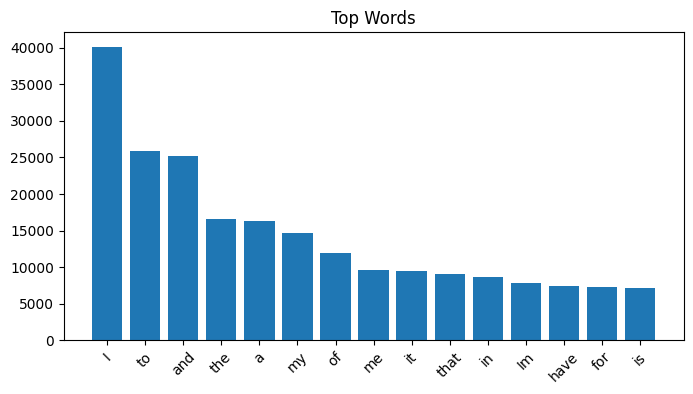

In [3]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from collections import Counter

# Load dataset
df = pd.read_csv("data_to_be_cleansed.csv")

# Drop duplicates if text + title exist
subset_cols = [c for c in ['text', 'title'] if c in df.columns]
if subset_cols:
    df = df.drop_duplicates(subset=subset_cols)

# Cleaning function
def basic_clean(text):
    text = str(text)
    text = re.sub(r'http\S+', '', text)  # URLs
    text = re.sub(r'\[.*?\]', '', text)  # Reddit links
    text = re.sub(r'\b\d{1,3}\s*[mMfF]\b', '', text)  # 19M
    text = re.sub(r'\b[mMfF]/\d{1,3}\b', '', text)  # M/21
    text = re.sub(r'\b\d+\b', '', text)  # numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # non-letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
if 'text' in df.columns:
    df['clean_text'] = df['text'].apply(basic_clean)
if 'title' in df.columns:
    df['clean_title'] = df['title'].apply(basic_clean)

# --- Visualization: Word frequency before vs after ---
def plot_word_freq(column, title):
    if column not in df.columns:
        print(f"Column {column} not found, skipping {title}")
        return
    words = " ".join(df[column].dropna()).split()
    if not words:
        print(f"No words found for {title}")
        return
    common = Counter(words).most_common(15)
    labels, counts = zip(*common)
    plt.figure(figsize=(8,4))
    plt.bar(labels, counts)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

plot_word_freq('clean_text', "Top Words")
